In [104]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()


  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [105]:
using Revise
using Statistics
using CairoMakie
includet("analysis.jl")


In [106]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [107]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

# Link-Degree Skew vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the skew of the link-degree distribution for each sample, aggregates those skews with
`aggregate_hist_moment`, and plots the mean skew with asymmetric error bars as a function of size.

In [109]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function manifoldlike_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_1000$", name)
        msm = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        if size < 1024
            continue
        end
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs = manifoldlike_size_path_pairs(analysis_root)
sizes = first.(size_path_pairs)
paths = last.(size_path_pairs)

sizes


7-element Vector{Int64}:
  1024
  2048
  4096
  8192
 16384
 32768
 65536

In [110]:
degree_hists = CausalSetZoology.load_histograms_from_paths(paths, :degree_hist_link)

7-element Vector{Vector{Dict}}:
 [Dict(5 => 19, 16 => 38, 20 => 5, 7 => 75, 12 => 101, 8 => 105, 17 => 25, 23 => 1, 19 => 8, 4 => 9…), Dict(5 => 38, 16 => 30, 20 => 5, 12 => 106, 24 => 1, 8 => 117, 17 => 24, 19 => 9, 22 => 1, 6 => 52…), Dict(5 => 29, 16 => 40, 20 => 3, 7 => 79, 12 => 105, 8 => 83, 17 => 14, 19 => 8, 22 => 1, 4 => 13…), Dict(5 => 34, 16 => 42, 20 => 6, 7 => 72, 12 => 94, 8 => 85, 17 => 17, 23 => 2, 19 => 7, 4 => 9…), Dict(5 => 27, 16 => 36, 20 => 7, 12 => 99, 24 => 1, 8 => 104, 17 => 21, 19 => 10, 22 => 2, 6 => 28…), Dict(5 => 39, 16 => 31, 20 => 4, 7 => 62, 12 => 131, 8 => 98, 17 => 17, 1 => 1, 19 => 12, 4 => 27…), Dict(5 => 55, 16 => 20, 20 => 3, 12 => 86, 8 => 112, 17 => 16, 1 => 1, 19 => 3, 22 => 2, 23 => 1…), Dict(5 => 37, 16 => 21, 20 => 1, 12 => 105, 8 => 106, 17 => 15, 1 => 1, 19 => 5, 22 => 1, 6 => 49…), Dict(5 => 38, 16 => 33, 20 => 5, 12 => 94, 24 => 1, 8 => 90, 17 => 32, 23 => 2, 19 => 9, 22 => 2…), Dict(5 => 30, 16 => 36, 20 => 1, 7 => 82, 12 => 116, 8 => 9

In [111]:
skew_stats = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists
]

skew_means = getfield.(skew_stats, :mean)
skew_stds = getfield.(skew_stats, :std)
skew_lows = getfield.(skew_stats, :std_lo)
skew_highs = getfield.(skew_stats, :std_hi)

all(skew_means .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes[i], mean = skew_means[i], std = skew_stds[i], std_lo = skew_lows[i], std_hi = skew_highs[i]) for i in eachindex(sizes)]

7-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 1024, mean = 0.2800662334430917, std = 0.10480409045058729, std_lo = 0.09044754221776014, std_hi = 0.09667691630788872)
 (size = 2048, mean = 0.24650175532852178, std = 0.08052310142539658, std_lo = 0.06435300005591091, std_hi = 0.07636133945116394)
 (size = 4096, mean = 0.21729534244664858, std = 0.056565577047086056, std_lo = 0.04663002016151288, std_hi = 0.05147719504857168)
 (size = 8192, mean = 0.19466747725026556, std = 0.04379085777913112, std_lo = 0.038027952709550505, std_hi = 0.038801520516973415)
 (size = 16384, mean = 0.1752258588290511, std = 0.033721990182766025, std_lo = 0.026181821843049374, std_hi = 0.027457049417094315)
 (size = 32768, mean = 0.16134480901978984, std = 0.026566795755070493, std_lo = 0.01725217451842001, std_hi = 0.021187507440722703)
 (size = 65536, mean = 0.14989270039517522, std = 0.02278573415170145, std_lo = 0.01427082923322498, std_

In [228]:
f(x, p) = p.A * x^(-p.α)

fit = fit_curve(
    Float64.(skew_means),
    f,
    (:A, :α);
    x_values = Float64.(sizes),
    stds = Float64.(skew_stds),
    init = (A = 1.0, α = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit.params

println("χ²=" * string(fit.χ²))
println("f=$(p.A)x^$(-p.α))")

xfit = 10 .^ range(log10(minimum(sizes)), log10(maximum(sizes)), length = 300)
yfit = f.(xfit, Ref(p));

χ²=0.011710089111879622
f=0.7180969876989044x^-0.14298041688555085)


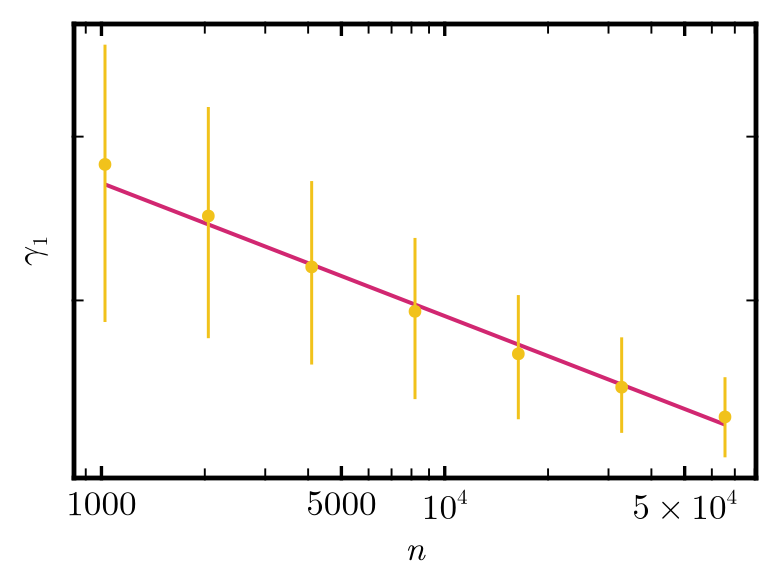

In [227]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
    xscale = log10,
    yscale = log10,
)

lines!(ax, xfit, yfit; color = colors[2], linewidth = 2)

errorbars!(ax, sizes, skew_means, skew_lows, skew_highs)
scatter!(ax, sizes, skew_means; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)
fig

In [321]:
f_log(x, p) = p.A / (log(x) + p.α)

fit_log = fit_curve(
    Float64.(skew_means),
    f_log,
    (:A, :α);
    x_values = Float64.(sizes),
    stds = Float64.(skew_stds),
    init = (A = 1.0, α = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit_log.params

println("χ²=" * string(fit_log.χ²))
println("f=$(p.A)/(log(x)$(p.α))")

xfit_log = 10 .^ range(log10(minimum(sizes)), log10(maximum(sizes)), length = 300)
yfit_log = f_log.(xfit_log, Ref(p));

χ²=0.0007931522031107659
f=1.3236715397023726/(log(x)-2.212725015129215)


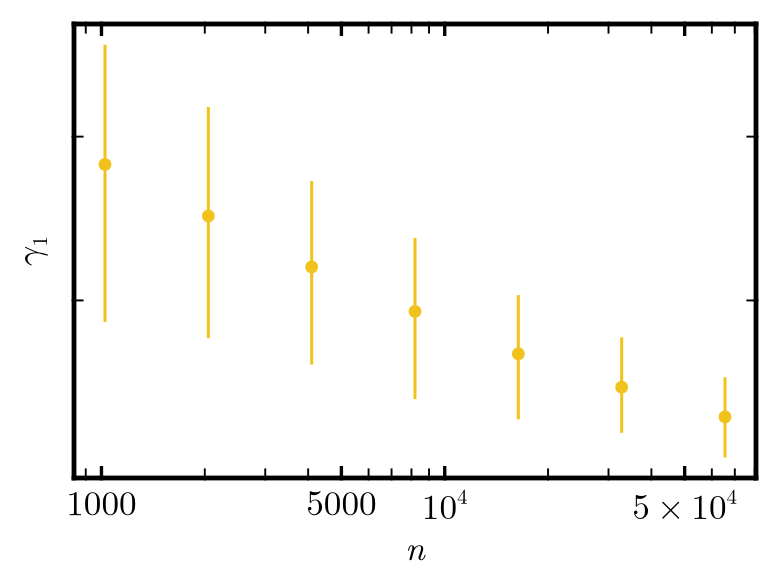

In [342]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
    xscale = log10,
    yscale = log10,
)

#lines!(ax, xfit_log, yfit_log; color = colors[2], linewidth = 2)

errorbars!(ax, sizes, skew_means, skew_lows, skew_highs)
scatter!(ax, sizes, skew_means; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)
fig

# Link-Degree Skew vs Size for Minkowski sprinklings

In [230]:
analysis_root_mink = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function minkowski_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^minkowski_sprinkling_link_degree_(\d+)_1000$", name)
        msm = match(r"^minkowski_sprinkling_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        if size < 1024
            continue
        end
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_minkowski = minkowski_size_path_pairs(analysis_root_mink)
sizes_minkowski = first.(size_path_pairs_minkowski)
paths_minkowski = last.(size_path_pairs_minkowski)

sizes_minkowski

11-element Vector{Int64}:
    1024
    2048
    4096
    8192
   16384
   32768
   65536
  131072
  262144
  524288
 1048576

In [232]:
degree_hists_minkowski = CausalSetZoology.load_histograms_from_paths(paths_minkowski, :degree_hist_link)

11-element Vector{Vector{Dict}}:
 [Dict(5 => 12, 16 => 40, 20 => 1, 7 => 62, 12 => 122, 8 => 75, 17 => 35, 19 => 12, 22 => 1, 4 => 7…), Dict(5 => 21, 16 => 27, 7 => 73, 12 => 113, 8 => 99, 17 => 24, 19 => 2, 4 => 2, 6 => 39, 13 => 88…), Dict(5 => 23, 16 => 40, 20 => 2, 7 => 75, 12 => 119, 24 => 1, 8 => 84, 17 => 19, 19 => 3, 4 => 4…), Dict(5 => 26, 16 => 30, 20 => 1, 12 => 112, 8 => 94, 17 => 17, 1 => 1, 19 => 2, 22 => 1, 6 => 39…), Dict(5 => 9, 16 => 27, 20 => 4, 7 => 57, 12 => 123, 8 => 83, 17 => 19, 23 => 1, 19 => 11, 22 => 1…), Dict(5 => 13, 16 => 34, 20 => 3, 7 => 65, 12 => 123, 8 => 84, 17 => 16, 19 => 5, 4 => 1, 6 => 31…), Dict(5 => 14, 16 => 31, 20 => 2, 7 => 70, 12 => 125, 8 => 97, 17 => 22, 19 => 4, 4 => 6, 6 => 21…), Dict(5 => 16, 16 => 42, 20 => 2, 7 => 61, 12 => 133, 8 => 92, 17 => 18, 19 => 7, 4 => 6, 6 => 32…), Dict(5 => 14, 16 => 43, 20 => 4, 7 => 68, 12 => 137, 8 => 82, 17 => 24, 23 => 1, 19 => 6, 22 => 1…), Dict(5 => 22, 16 => 25, 20 => 1, 7 => 56, 12 => 134, 8 => 101

In [233]:
skew_stats_minkowski = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists_minkowski
]

skew_means_minkowski = getfield.(skew_stats_minkowski, :mean)
skew_stds_minkowski = getfield.(skew_stats_minkowski, :std)
skew_lows_minkowski = getfield.(skew_stats_minkowski, :std_lo)
skew_highs_minkowski = getfield.(skew_stats_minkowski, :std_hi)

all(skew_means_minkowski .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes_minkowski[i], mean = skew_means_minkowski[i], std = skew_stds_minkowski[i], std_lo = skew_lows_minkowski[i], std_hi = skew_highs_minkowski[i]) for i in eachindex(sizes_minkowski)]

11-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 1024, mean = 0.25517991100568693, std = 0.0843177972911055, std_lo = 0.08373731679614213, std_hi = 0.08465021211602286)
 (size = 2048, mean = 0.24951461144573703, std = 0.06142209517880349, std_lo = 0.05969304397255251, std_hi = 0.061561912293536886)
 (size = 4096, mean = 0.23997753972534858, std = 0.040885628544118, std_lo = 0.03762949239911942, std_hi = 0.043797342518013704)
 (size = 8192, mean = 0.2319051965700888, std = 0.029075635995191945, std_lo = 0.027087876222033735, std_hi = 0.028795706643499064)
 (size = 16384, mean = 0.22516858703624745, std = 0.02155592296243637, std_lo = 0.022104518234578957, std_hi = 0.020979427888681595)
 (size = 32768, mean = 0.21761725482025804, std = 0.015278761197281523, std_lo = 0.01503798713253826, std_hi = 0.01559572671420098)
 (size = 65536, mean = 0.21032419987331338, std = 0.010193513746588443, std_lo = 0.010537397884860106, std

In [234]:
f(x, p) = p.A * x^(-p.α)

fit_minkowski = fit_curve(
    Float64.(skew_means_minkowski),
    f,
    (:A, :α);
    x_values = Float64.(sizes_minkowski),
    stds = Float64.(skew_stds_minkowski),
    init = (A = 1.0, α = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit_minkowski.params

println("χ²=" * string(fit_minkowski.χ²))
println("f=$(p.A)x^$(-p.α))")

xfit_minkowski = 10 .^ range(log10(minimum(sizes_minkowski)), log10(maximum(sizes_minkowski)), length = 300)
yfit_minkowski = f.(xfit_minkowski, Ref(p));



χ²=0.015916157640796798
f=0.3257049345907225x^-0.0391256973728755)


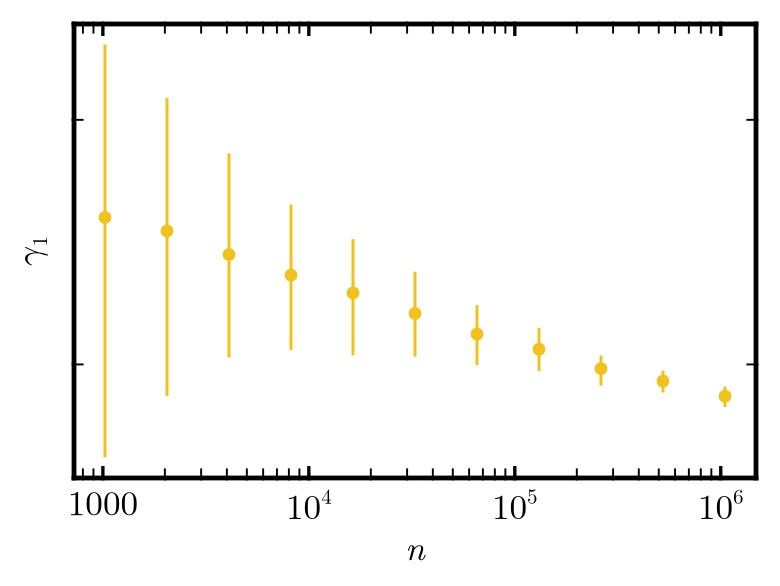

In [341]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
    xscale = log10,
    yscale = log10,
)

#band!(ax, xfit_minkowski, lower_minkowski, upper_minkowski; color = (colors[2], 0.15))
#lines!(ax, xfit_minkowski, yfit_minkowski; color = colors[2], linewidth = 2)

errorbars!(ax, sizes_minkowski, skew_means_minkowski, skew_lows_minkowski, skew_highs_minkowski)
scatter!(ax, sizes_minkowski, skew_means_minkowski; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling_minkowski.pdf"), fig)
fig


In [329]:
f_log(x, p) = p.A / (log(x) + p.α)

fit_log_minkowski = fit_curve(
    Float64.(skew_means_minkowski),
    f_log,
    (:A, :α);
    x_values = Float64.(sizes_minkowski),
    stds = Float64.(skew_stds_minkowski),
    init = (A = 1.0, α = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit_log_minkowski.params

println("χ²=" * string(fit_log_minkowski.χ²))
println("f=$(p.A)/(log(x)) + $(p.α)")

xfit_log_minkowski = 10 .^ range(log10(minimum(sizes_minkowski)), log10(maximum(sizes_minkowski)), length = 300)
yfit_log_minkowski = f_log.(xfit_log_minkowski, Ref(p));

χ²=0.007031279703943018
f=5.182505819802744/(log(x)) + 13.483604882445345


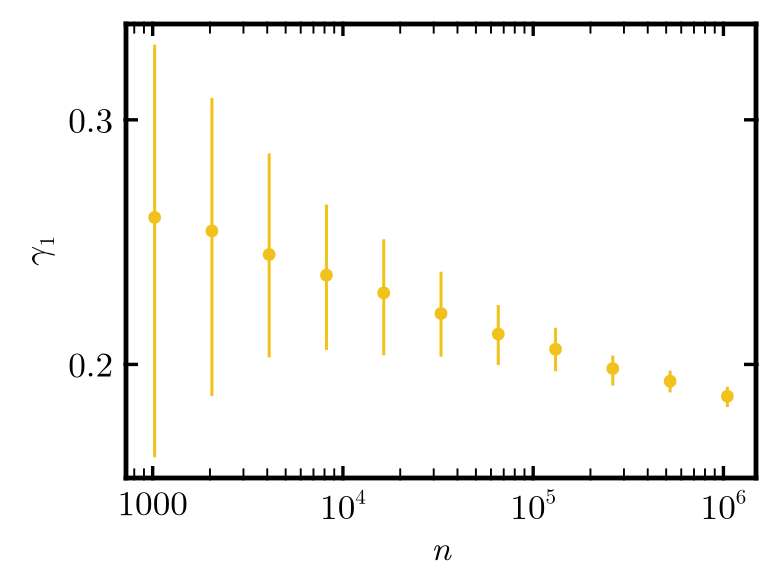

In [340]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
    xscale = log10,
    yscale = log10,
    yticks = [0.1, 0.2, 0.3]
)

#band!(ax, xfit_log_minkowski, lower_log_minkowski, upper_log_minkowski; color = (colors[2], 0.15))
#lines!(ax, xfit_log_minkowski, yfit_log_minkowski; color = colors[2], linewidth = 2)

errorbars!(ax, sizes_minkowski, skew_means_minkowski, skew_lows_minkowski, skew_highs_minkowski)
scatter!(ax, sizes_minkowski, skew_means_minkowski; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling_minkowski.pdf"), fig)
fig


In [244]:
f_taylor(x, p) = p.A + p.B / log(x)

fit_taylor_minkowski = fit_curve(
    Float64.(skew_means_minkowski),
    f_taylor,
    (:A, :B);
    x_values = Float64.(sizes_minkowski),
    stds = Float64.(skew_stds_minkowski),
    init = (A = 1.0, B = 1.0, C = 1.0, D = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit_taylor_minkowski.params

println("χ²=" * string(fit_taylor_minkowski.χ²))
println("f=$(p.A)+$(p.B)/log(x)")

xfit_taylor_minkowski = 10 .^ range(log10(minimum(sizes_minkowski)), log10(maximum(sizes_minkowski)), length = 300)
yfit_taylor_minkowski = f_taylor.(xfit_taylor_minkowski, Ref(p));

χ²=0.010126753562866707
f=0.10977124172984293+1.1122662469722013/log(x)


In [246]:
f_taylor(x, p) = p.A + p.B / log(x) + p.C / x + p.D / x^2

fit_taylor_minkowski = fit_curve(
    Float64.(skew_means_minkowski),
    f_taylor,
    (:A, :B, :C, :D);
    x_values = Float64.(sizes_minkowski),
    stds = Float64.(skew_stds_minkowski),
    init = (A = 1.0, B = 1.0, C = 1.0, D = 1.0),
    minimize_χ² = true,
    multistart = 1000,
    goodness_of_fit = true,
)

p = fit_taylor_minkowski.params

println("χ²=" * string(fit_taylor_minkowski.χ²))
println("f=$(p.A)+$(p.B)/log(x)+$(p.C)/x+$(p.D)/x^2")

xfit_taylor_minkowski = 10 .^ range(log10(minimum(sizes_minkowski)), log10(maximum(sizes_minkowski)), length = 300)
yfit_taylor_minkowski = f_taylor.(xfit_taylor_minkowski, Ref(p));

χ²=0.0035746332441653835
f=0.10533141980584738+1.1715633580629126/log(x)+-21.424014659866003/x+997.0411893849291/x^2


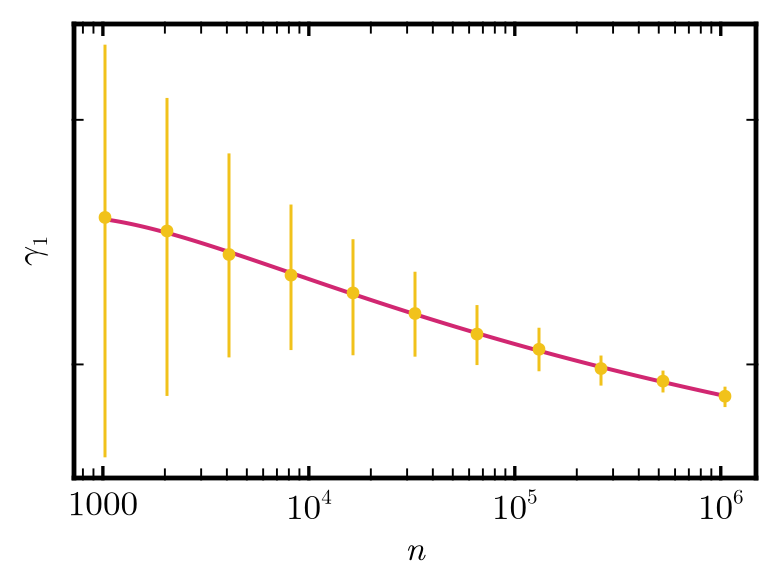

In [247]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
    xscale = log10,
    yscale = log10,
)

#band!(ax, xfit_taylor_minkowski, lower_taylor_minkowski, upper_taylor_minkowski; color = (colors[2], 0.15))
lines!(ax, xfit_taylor_minkowski, yfit_taylor_minkowski; color = colors[2], linewidth = 2)

errorbars!(ax, sizes_minkowski, skew_means_minkowski, skew_lows_minkowski, skew_highs_minkowski)
scatter!(ax, sizes_minkowski, skew_means_minkowski; marker = :circle)

#save(fig_path("graph_observables/degree_skew_size_scaling_minkowski.pdf"), fig)
fig

In [248]:
function tail_fit_zero_vs_const(ns, ys, σs; min_points = 6, multistart = 100)
    results = NamedTuple[]
    N = length(ns)

    for k in 1:(N - min_points + 1)
        ns_tail = Float64.(ns[k:end])
        ys_tail = Float64.(ys[k:end])
        σs_tail = Float64.(σs[k:end])

        fit0 = fit_curve(
            ys_tail,
            (n, p) -> p.A * n^(-p.α),
            (:A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (A = maximum(ys_tail), α = 1.0),
            bounds = ((A = 0.0, α = 0.0), (A = Inf, α = 10.0)),
            minimize_χ² = true,
            goodness_of_fit = true,
            multistart = multistart,
        )

        fit1 = fit_curve(
            ys_tail,
            (n, p) -> p.c + p.A * n^(-p.α),
            (:c, :A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (c = ys_tail[end], A = maximum(ys_tail), α = 1.0),
            bounds = ((c = -Inf, A = 0.0, α = 0.0), (c = Inf, A = Inf, α = 10.0)),
            minimize_χ² = true,
            goodness_of_fit = true,
            return_cov = true,
            multistart = multistart,
        )

        push!(results, (
            n_min = ns_tail[1],
            n_points = length(ns_tail),
            fit_zero = fit0,
            fit_const = fit1,
        ))
    end

    results
end


tail_fit_zero_vs_const (generic function with 1 method)

A_zero =[0.3257051025345681, 0.3251297536839642, 0.3239890083988686, 0.3224583119399244, 0.32046222164228144, 0.317383963112157]
α_zero =[0.03912573219682479, 0.03899171518485659, 0.0387257382332598, 0.038368133383064905, 0.03790049908687732, 0.037176020560954065]
A_const =[0.28739007728491633, 0.2963271288417141, 0.2992843426551275, 0.3087583610157361, 0.32551528746407365, 0.31385493934644937]
c_const =[0.14032492733383312, 0.14327611846856045, 0.14410309802540994, 0.14637870943974784, 0.1495112046961074, 0.14750656184357588]
α_const =[0.1269750114228394, 0.13359564866541743, 0.13559868242829254, 0.14151232581862688, 0.1506980223955758, 0.14457877580443196]
χ²_zero=[0.01591615764345137, 0.01705771515103402, 0.016961922956490568, 0.016868427559149277, 0.01660346159560542, 0.013768432775075992]
χ²_const=[0.0036119457885466022, 0.0036510334172024086, 0.004225102631370237, 0.004882474077771866, 0.005814745520265744, 0.007666827951073168]


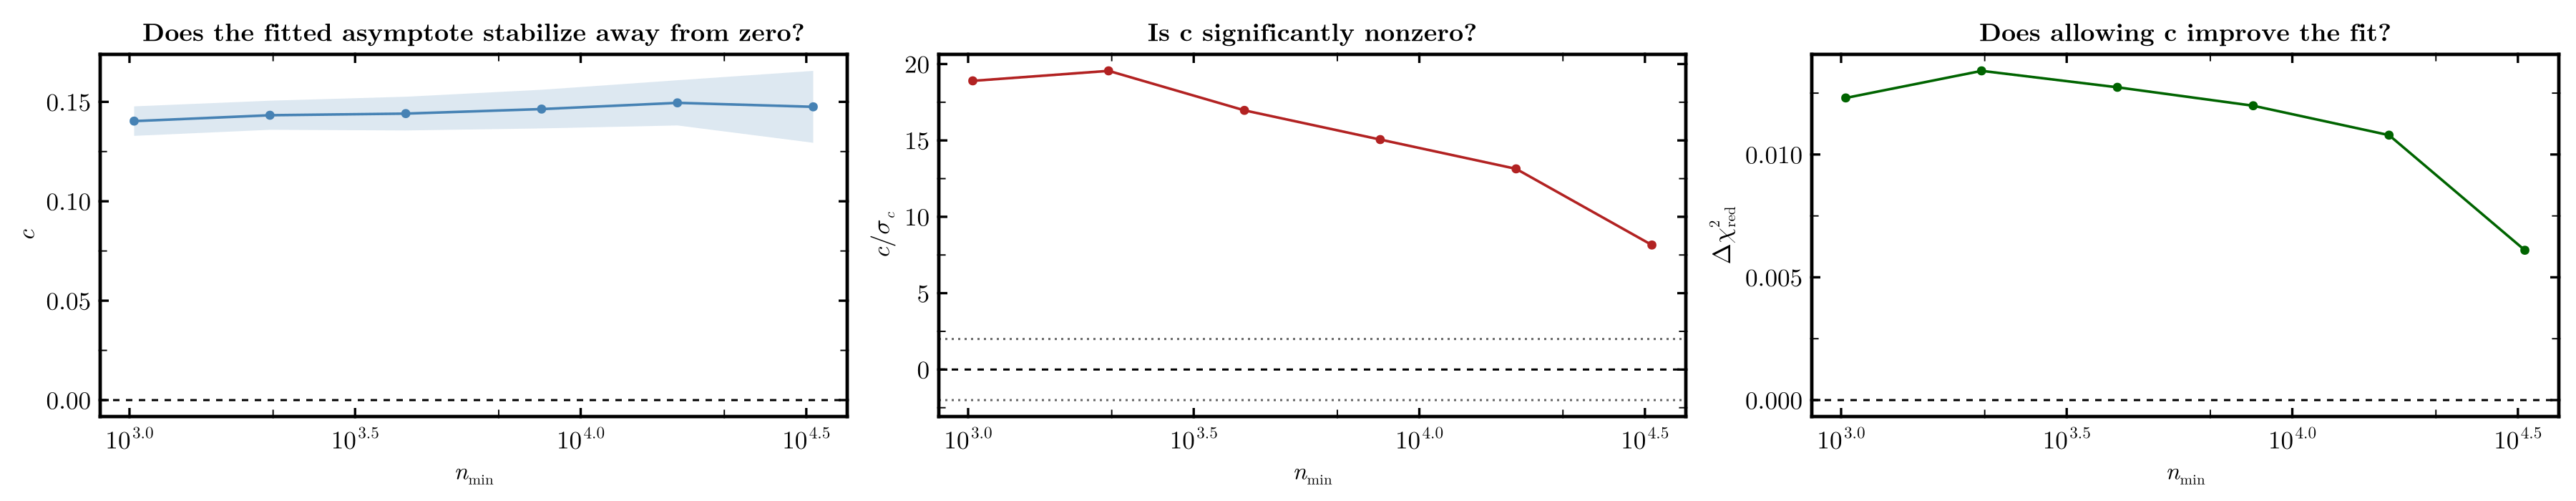

In [271]:
res_minkowski = tail_fit_zero_vs_const(Float64.(sizes_minkowski), Float64.(skew_means_minkowski), Float64.(skew_stds_minkowski))

using CairoMakie
using Statistics

n_min_vals = [r.n_min for r in res_minkowski]
n_points_vals = [r.n_points for r in res_minkowski]

χ²_zero = [r.fit_zero.χ² for r in res_minkowski]
χ²_const = [r.fit_const.χ² for r in res_minkowski]

A_zero = [r.fit_zero.params.A for r in res_minkowski]
α_zero = [r.fit_zero.params.α for r in res_minkowski]

c_const = [r.fit_const.params.c for r in res_minkowski]
A_const = [r.fit_const.params.A for r in res_minkowski]
α_const = [r.fit_const.params.α for r in res_minkowski]

c_err = [r.fit_const.stderr.c for r in res_minkowski]
A_const_err = [r.fit_const.stderr.A for r in res_minkowski]
α_const_err = [r.fit_const.stderr.α for r in res_minkowski]

Δχ² = χ²_zero .- χ²_const
z_c = c_const ./ c_err


println("A_zero =$A_zero")
println("α_zero =$α_zero")
println("A_const =$A_const")
println("c_const =$c_const")
println("α_const =$α_const")
println("χ²_zero=$χ²_zero")
println("χ²_const=$χ²_const")

fig_summary = Figure(size = (1800, 350))

ax1 = Axis(
    fig_summary[1, 1];
    xlabel = L"n_{\min}",
    ylabel = L"c",
    title = "Does the fitted asymptote stabilize away from zero?",
)
band!(ax1, n_min_vals, c_const .- c_err, c_const .+ c_err; color = (:steelblue, 0.18))
lines!(ax1, n_min_vals, c_const; color = :steelblue)
scatter!(ax1, n_min_vals, c_const; color = :steelblue)
hlines!(ax1, [0.0]; color = :black, linestyle = :dash)

ax2 = Axis(
    fig_summary[1, 2];
    xlabel = L"n_{\min}",
    ylabel = L"c/\sigma_c",
    title = "Is c significantly nonzero?",
)
hlines!(ax2, [0.0]; color = :black, linestyle = :dash)
hlines!(ax2, [2.0]; color = :gray40, linestyle = :dot)
hlines!(ax2, [-2.0]; color = :gray40, linestyle = :dot)
lines!(ax2, n_min_vals, z_c; color = :firebrick)
scatter!(ax2, n_min_vals, z_c; color = :firebrick)

ax3 = Axis(
    fig_summary[1, 3];
    xlabel = L"n_{\min}",
    ylabel = L"\Delta \chi^2_{\mathrm{red}}",
    title = "Does allowing c improve the fit?",
)
hlines!(ax3, [0.0]; color = :black, linestyle = :dash)
lines!(ax3, n_min_vals, Δχ²; color = :darkgreen)
scatter!(ax3, n_min_vals, Δχ²; color = :darkgreen)

for ax in (ax1, ax2, ax3)
    ax.xscale = log10
end


save(fig_path("graph_observables/degree_skew_size_scaling_minkowski_asymptotic.pdf"), fig_summary)


fig_summary


In [339]:
0.28*(1e6)^0.127

1.6186689327360109

In [263]:
function tail_fit_zero_vs_const_log(ns, ys, σs; min_points = 6, multistart = 100)
    results = NamedTuple[]
    N = length(ns)

    for k in 1:(N - min_points + 1)
        ns_tail = Float64.(ns[k:end])
        ys_tail = Float64.(ys[k:end])
        σs_tail = Float64.(σs[k:end])

        any(n -> n <= 1, ns_tail) && error("log model requires n > 1")

        fit0 = fit_curve(
            ys_tail,
            (n, p) -> p.A / (log(n)^p.α),
            (:A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (A = maximum(ys_tail) * log(ns_tail[1]), α = 1.0),
            bounds = ((A = 0.0, α = 0.0), (A = Inf, α = 10.0)),
            minimize_χ² = true,
            goodness_of_fit = true,
            multistart = multistart,
        )

        fit1 = fit_curve(
            ys_tail,
            (n, p) -> p.c + p.A / (log(n)^p.α),
            (:c, :A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (c = ys_tail[end], A = maximum(ys_tail) * log(ns_tail[1]), α = 1.0),
            bounds = ((c = -Inf, A = 0.0, α = 0.0), (c = Inf, A = Inf, α = 10.0)),
            minimize_χ² = true,
            goodness_of_fit = true,
            return_cov = true,
            multistart = multistart,
        )

        push!(results, (
            n_min = ns_tail[1],
            n_points = length(ns_tail),
            fit_zero = fit0,
            fit_const = fit1,
        ))
    end

    results
end


tail_fit_zero_vs_const_log (generic function with 1 method)

A_zero =[0.6441436627866362, 0.6474718009466698, 0.6485285563821845, 0.6500432345334906, 0.6507275001808469, 0.646053225172372]
α_zero =[0.4648490777518417, 0.46685054710972895, 0.467483377604544, 0.46838770099758636, 0.46879505010366673, 0.4660080187641872]
A_const =[0.6388076468907925, 0.6551716400965835, 0.6761730188639137, 0.7412556128998222, 0.889716682996042, 0.855140227152829]
c_const =[-0.0402308361344894, 0.012397782316274525, 0.0304146390391239, 0.05796201128447481, 0.08502008398037578, 0.08060604951962996]
α_const =[0.38860933340226317, 0.4970218878674864, 0.5497407062700306, 0.6568283243587897, 0.8135656871077217, 0.782807297215542]
χ²_zero=[0.0038226256624481095, 0.0034683111727339786, 0.0038952909938996905, 0.004449937023207929, 0.005325479668346561, 0.00609890888452181]
χ²_const=[0.004196214930802691, 0.003949268004010598, 0.004449515149097563, 0.004934680936024616, 0.005626912177649112, 0.007488965736232703]


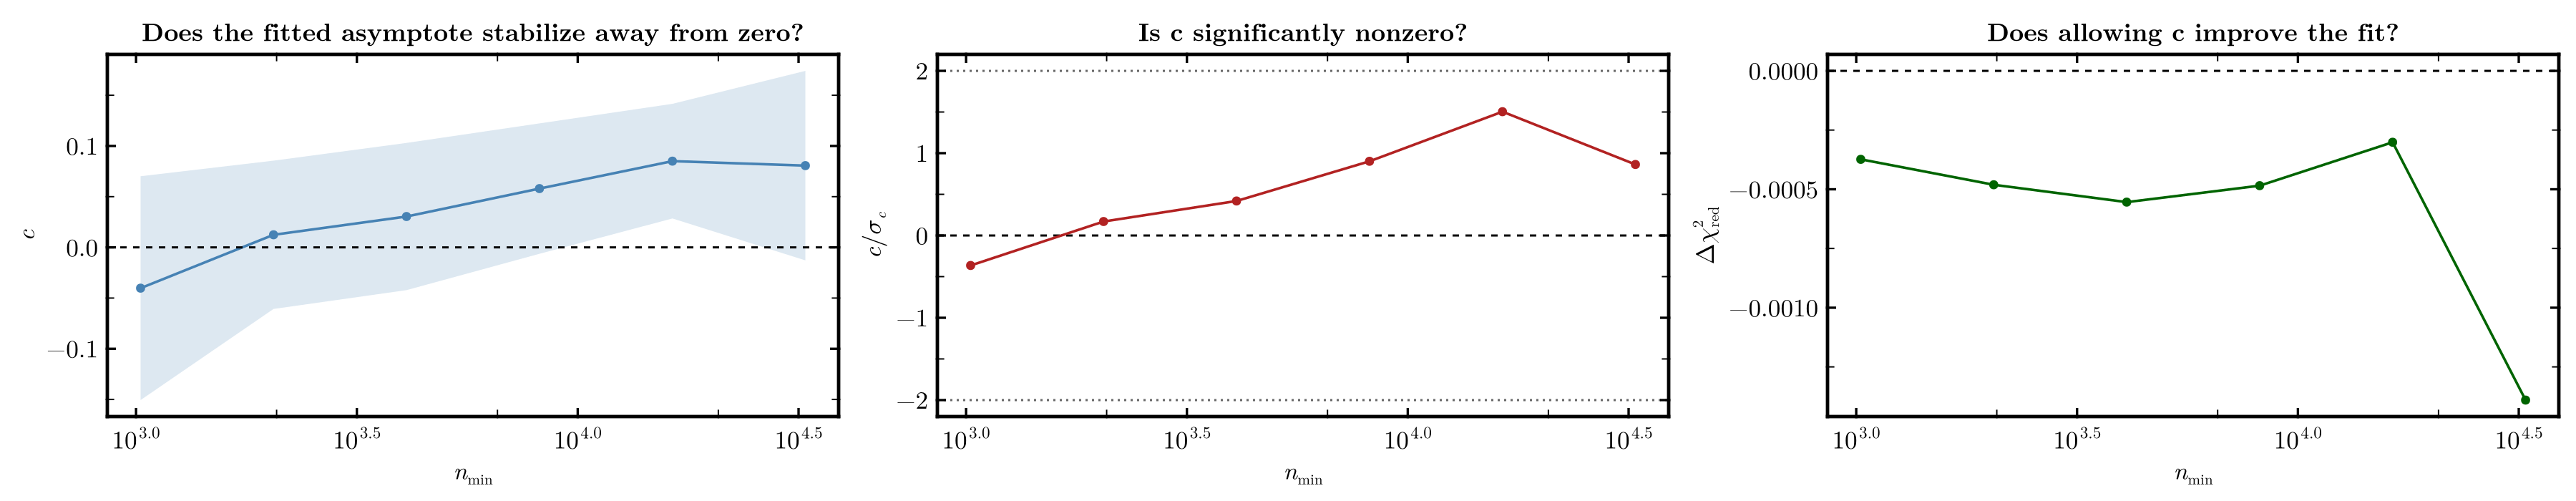

In [272]:
res_minkowski = tail_fit_zero_vs_const_log(Float64.(sizes_minkowski), Float64.(skew_means_minkowski), Float64.(skew_stds_minkowski))

using CairoMakie
using Statistics

n_min_vals = [r.n_min for r in res_minkowski]
n_points_vals = [r.n_points for r in res_minkowski]

χ²_zero = [r.fit_zero.χ² for r in res_minkowski]
χ²_const = [r.fit_const.χ² for r in res_minkowski]

A_zero = [r.fit_zero.params.A for r in res_minkowski]
α_zero = [r.fit_zero.params.α for r in res_minkowski]

c_const = [r.fit_const.params.c for r in res_minkowski]
A_const = [r.fit_const.params.A for r in res_minkowski]
α_const = [r.fit_const.params.α for r in res_minkowski]

c_err = [r.fit_const.stderr.c for r in res_minkowski]
A_const_err = [r.fit_const.stderr.A for r in res_minkowski]
α_const_err = [r.fit_const.stderr.α for r in res_minkowski]


println("A_zero =$A_zero")
println("α_zero =$α_zero")
println("A_const =$A_const")
println("c_const =$c_const")
println("α_const =$α_const")
println("χ²_zero=$χ²_zero")
println("χ²_const=$χ²_const")

Δχ² = χ²_zero .- χ²_const
z_c = c_const ./ c_err

fig_summary = Figure(size = (1800, 350))

ax1 = Axis(
    fig_summary[1, 1];
    xlabel = L"n_{\min}",
    ylabel = L"c",
    title = "Does the fitted asymptote stabilize away from zero?",
)
band!(ax1, n_min_vals, c_const .- c_err, c_const .+ c_err; color = (:steelblue, 0.18))
lines!(ax1, n_min_vals, c_const; color = :steelblue)
scatter!(ax1, n_min_vals, c_const; color = :steelblue)
hlines!(ax1, [0.0]; color = :black, linestyle = :dash)

ax2 = Axis(
    fig_summary[1, 2];
    xlabel = L"n_{\min}",
    ylabel = L"c/\sigma_c",
    title = "Is c significantly nonzero?",
)
hlines!(ax2, [0.0]; color = :black, linestyle = :dash)
hlines!(ax2, [2.0]; color = :gray40, linestyle = :dot)
hlines!(ax2, [-2.0]; color = :gray40, linestyle = :dot)
lines!(ax2, n_min_vals, z_c; color = :firebrick)
scatter!(ax2, n_min_vals, z_c; color = :firebrick)

ax3 = Axis(
    fig_summary[1, 3];
    xlabel = L"n_{\min}",
    ylabel = L"\Delta \chi^2_{\mathrm{red}}",
    title = "Does allowing c improve the fit?",
)
hlines!(ax3, [0.0]; color = :black, linestyle = :dash)
lines!(ax3, n_min_vals, Δχ²; color = :darkgreen)
scatter!(ax3, n_min_vals, Δχ²; color = :darkgreen)

for ax in (ax1, ax2, ax3)
    ax.xscale = log10
end


save(fig_path("graph_observables/degree_skew_size_scaling_minkowski_asymptotic.pdf"), fig_summary)


fig_summary


In [276]:
function tail_fit_zero_vs_const_log_2(ns, ys, σs; min_points = 6, multistart = 100)
    results = NamedTuple[]
    N = length(ns)

    for k in 1:(N - min_points + 1)
        ns_tail = Float64.(ns[k:end])
        ys_tail = Float64.(ys[k:end])
        σs_tail = Float64.(σs[k:end])

        any(n -> n <= 1, ns_tail) && error("log model requires n > 1")

        fit0 = fit_curve(
            ys_tail,
            (n, p) -> p.A / (log(n) + p.α),
            (:A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (A = maximum(ys_tail) * log(ns_tail[1]), α = 1.0),
            bounds = ((A = 0.0, α = 0.0), (A = Inf, α = Inf)),
            minimize_χ² = true,
            goodness_of_fit = true,
            multistart = multistart,
        )

        fit1 = fit_curve(
            ys_tail,
            (n, p) -> p.c + p.A / (log(n) + p.α),
            (:c, :A, :α);
            x_values = ns_tail,
            stds = σs_tail,
            init = (c = ys_tail[end], A = maximum(ys_tail) * log(ns_tail[1]), α = 1.0),
            bounds = ((c = -Inf, A = 0.0, α = 0.0), (c = Inf, A = Inf, α = Inf)),
            minimize_χ² = true,
            goodness_of_fit = true,
            return_cov = true,
            multistart = multistart,
        )

        push!(results, (
            n_min = ns_tail[1],
            n_points = length(ns_tail),
            fit_zero = fit0,
            fit_const = fit1,
        ))
    end

    results
end

tail_fit_zero_vs_const_log_2 (generic function with 1 method)

A_zero =[5.182520281644812, 5.186494813336617, 5.206695876949642, 5.23231765128799, 5.268444179625621, 5.3409337385779825]
α_zero =[13.48368167076527, 13.504089637928724, 13.607948525075827, 13.739838740674, 13.92609135238687, 14.300512624879564]
A_const =[2.2409277767257274, 1.9680467788351905, 1.861598821950901, 1.6526842105327089, 1.3923320903970313, 1.4429088352766413]
c_const =[0.06992952916891979, 0.07815765276932131, 0.08150246319195971, 0.08830784541702193, 0.09734975023796283, 0.09554976602190751]
α_const =[4.84292622599642, 3.7728118137262543, 3.332868544324857, 2.4242551382700235, 1.197112787394115, 1.4467084641187373]
χ²_zero=[0.00703127973577884, 0.007878032550538145, 0.008346287023037, 0.009045727682638772, 0.009849037198540125, 0.009127322027539051]
χ²_const=[0.003973661410559491, 0.003847624941974039, 0.0043796128627732675, 0.004914719484992421, 0.005640966963055422, 0.007506259559255422]


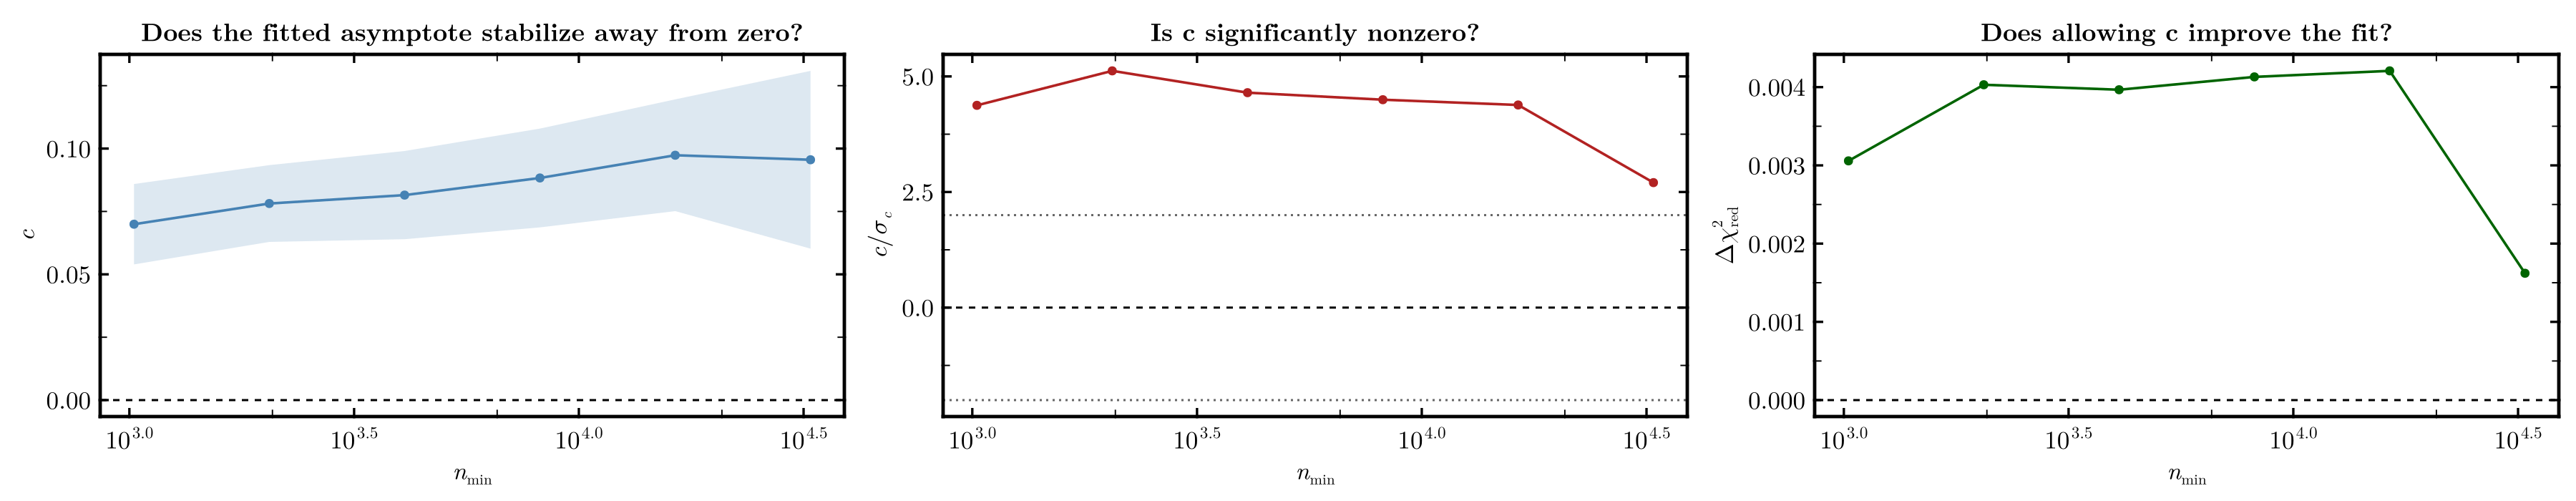

In [277]:
res_minkowski = tail_fit_zero_vs_const_log_2(Float64.(sizes_minkowski), Float64.(skew_means_minkowski), Float64.(skew_stds_minkowski))

using CairoMakie
using Statistics

n_min_vals = [r.n_min for r in res_minkowski]
n_points_vals = [r.n_points for r in res_minkowski]

χ²_zero = [r.fit_zero.χ² for r in res_minkowski]
χ²_const = [r.fit_const.χ² for r in res_minkowski]

A_zero = [r.fit_zero.params.A for r in res_minkowski]
α_zero = [r.fit_zero.params.α for r in res_minkowski]

c_const = [r.fit_const.params.c for r in res_minkowski]
A_const = [r.fit_const.params.A for r in res_minkowski]
α_const = [r.fit_const.params.α for r in res_minkowski]

c_err = [r.fit_const.stderr.c for r in res_minkowski]
A_const_err = [r.fit_const.stderr.A for r in res_minkowski]
α_const_err = [r.fit_const.stderr.α for r in res_minkowski]

println("A_zero =$A_zero")
println("α_zero =$α_zero")
println("A_const =$A_const")
println("c_const =$c_const")
println("α_const =$α_const")
println("χ²_zero=$χ²_zero")
println("χ²_const=$χ²_const")

Δχ² = χ²_zero .- χ²_const
z_c = c_const ./ c_err

fig_summary = Figure(size = (1800, 350))

ax1 = Axis(
    fig_summary[1, 1];
    xlabel = L"n_{\min}",
    ylabel = L"c",
    title = "Does the fitted asymptote stabilize away from zero?",
)
band!(ax1, n_min_vals, c_const .- c_err, c_const .+ c_err; color = (:steelblue, 0.18))
lines!(ax1, n_min_vals, c_const; color = :steelblue)
scatter!(ax1, n_min_vals, c_const; color = :steelblue)
hlines!(ax1, [0.0]; color = :black, linestyle = :dash)

ax2 = Axis(
    fig_summary[1, 2];
    xlabel = L"n_{\min}",
    ylabel = L"c/\sigma_c",
    title = "Is c significantly nonzero?",
)
hlines!(ax2, [0.0]; color = :black, linestyle = :dash)
hlines!(ax2, [2.0]; color = :gray40, linestyle = :dot)
hlines!(ax2, [-2.0]; color = :gray40, linestyle = :dot)
lines!(ax2, n_min_vals, z_c; color = :firebrick)
scatter!(ax2, n_min_vals, z_c; color = :firebrick)

ax3 = Axis(
    fig_summary[1, 3];
    xlabel = L"n_{\min}",
    ylabel = L"\Delta \chi^2_{\mathrm{red}}",
    title = "Does allowing c improve the fit?",
)
hlines!(ax3, [0.0]; color = :black, linestyle = :dash)
lines!(ax3, n_min_vals, Δχ²; color = :darkgreen)
scatter!(ax3, n_min_vals, Δχ²; color = :darkgreen)

for ax in (ax1, ax2, ax3)
    ax.xscale = log10
end


save(fig_path("graph_observables/degree_skew_size_scaling_minkowski_asymptotic.pdf"), fig_summary)


fig_summary

In [310]:
function tail_fit_zero_vs_const_log_3(ns, ys, σs; min_points = 6, multistart = 100)
    results = NamedTuple[]
    N = length(ns)

    for k in 1:(N - min_points + 1)
        ns_tail = Float64.(ns[k:end])
        ys_tail = Float64.(ys[k:end])
        σs_tail = Float64.(σs[k:end])

        any(n -> n <= 1, ns_tail) && error("log model requires n > 1")

        fit0 = fit_curve(
            ys_tail,
            (n, p) -> p.A / log(n),
            (:A,);
            x_values = ns_tail,
            stds = σs_tail,
            init = (A = maximum(ys_tail) * log(ns_tail[1]),),
            minimize_χ² = true,
            goodness_of_fit = true,
            multistart = multistart,
        )

        fit1 = fit_curve(
            ys_tail,
            (n, p) -> p.c + p.A / log(n),
            (:c, :A);
            x_values = ns_tail,
            stds = σs_tail,
            init = (c = ys_tail[end], A = maximum(ys_tail) * log(ns_tail[1])),
            minimize_χ² = true,
            goodness_of_fit = true,
            return_cov = true,
            multistart = multistart,
        )

        push!(results, (
            n_min = ns_tail[1],
            n_points = length(ns_tail),
            fit_zero = fit0,
            fit_const = fit1,
        ))
    end

    results
end


tail_fit_zero_vs_const_log_3 (generic function with 1 method)

A_zero =[2.52839673232859, 2.529792673755432, 2.5315931522971113, 2.534523977943872, 2.5386639790518366, 2.543903252684106]
A_const =[1.1122651284677247, 1.1239367851447342, 1.1324625936876922, 1.143577062967736, 1.1545101611061468, 1.1573733007666145]
c_const =[0.10977133460272978, 0.10888222267924258, 0.10823416317079906, 0.10739152100389351, 0.10656526257127824, 0.10634971048096803]
χ²_zero=[2.6117547560232746, 2.713904131545756, 2.8281986384986117, 2.8760526477812314, 2.870445966912891, 2.864523075950695]
χ²_const=[0.01012675356493646, 0.007195889408696133, 0.006364387185967266, 0.005272371086798801, 0.004748639504564164, 0.005846963476459462]


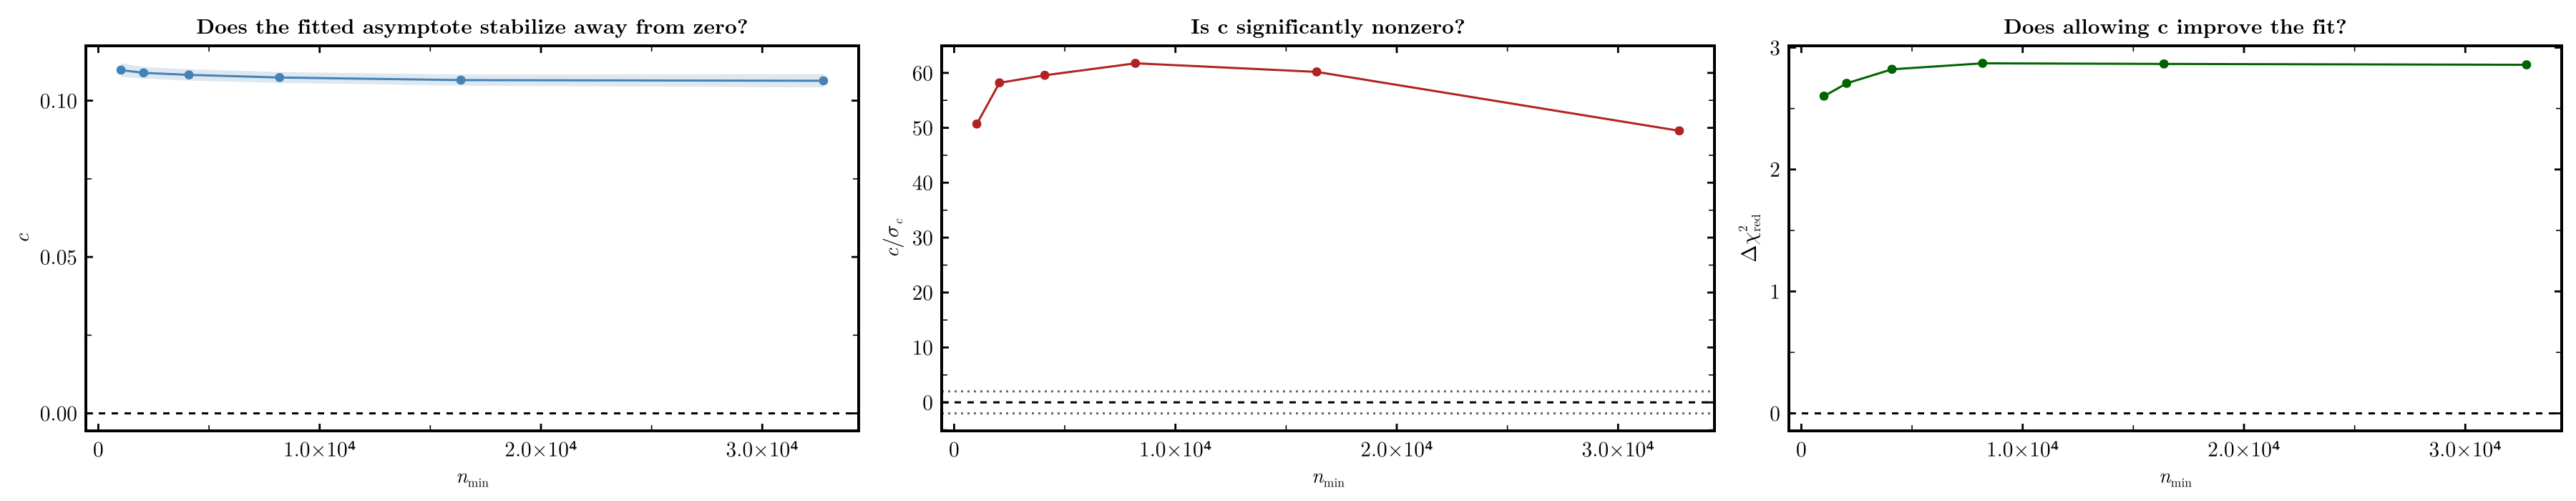

In [311]:
res_minkowski = tail_fit_zero_vs_const_log_3(Float64.(sizes_minkowski), Float64.(skew_means_minkowski), Float64.(skew_stds_minkowski))

apply_paper_theme!()

using CairoMakie
using Statistics

n_min_vals = [r.n_min for r in res_minkowski]
n_points_vals = [r.n_points for r in res_minkowski]

χ²_zero = [r.fit_zero.χ² for r in res_minkowski]
χ²_const = [r.fit_const.χ² for r in res_minkowski]

A_zero = [r.fit_zero.params.A for r in res_minkowski]

c_const = [r.fit_const.params.c for r in res_minkowski]
A_const = [r.fit_const.params.A for r in res_minkowski]

c_err = [r.fit_const.stderr.c for r in res_minkowski]
A_const_err = [r.fit_const.stderr.A for r in res_minkowski]


println("A_zero =$A_zero")
println("A_const =$A_const")
println("c_const =$c_const")
println("χ²_zero=$χ²_zero")
println("χ²_const=$χ²_const")

Δχ² = χ²_zero .- χ²_const
z_c = c_const ./ c_err

fig_summary = Figure(size = (1800, 350))

ax1 = Axis(
    fig_summary[1, 1];
    xlabel = L"n_{\min}",
    ylabel = L"c",
    title = "Does the fitted asymptote stabilize away from zero?",
)
band!(ax1, n_min_vals, c_const .- c_err, c_const .+ c_err; color = (:steelblue, 0.18))
lines!(ax1, n_min_vals, c_const; color = :steelblue)
scatter!(ax1, n_min_vals, c_const; color = :steelblue)
hlines!(ax1, [0.0]; color = :black, linestyle = :dash)

ax2 = Axis(
    fig_summary[1, 2];
    xlabel = L"n_{\min}",
    ylabel = L"c/\sigma_c",
    title = "Is c significantly nonzero?",
)
hlines!(ax2, [0.0]; color = :black, linestyle = :dash)
hlines!(ax2, [2.0]; color = :gray40, linestyle = :dot)
hlines!(ax2, [-2.0]; color = :gray40, linestyle = :dot)
lines!(ax2, n_min_vals, z_c; color = :firebrick)
scatter!(ax2, n_min_vals, z_c; color = :firebrick)

ax3 = Axis(
    fig_summary[1, 3];
    xlabel = L"n_{\min}",
    ylabel = L"\Delta \chi^2_{\mathrm{red}}",
    title = "Does allowing c improve the fit?",
)
hlines!(ax3, [0.0]; color = :black, linestyle = :dash)
lines!(ax3, n_min_vals, Δχ²; color = :darkgreen)
scatter!(ax3, n_min_vals, Δχ²; color = :darkgreen)


save(fig_path("graph_observables/degree_skew_size_scaling_minkowski_asymptotic.pdf"), fig_summary)


fig_summary

In [315]:
function tail_fit_zero_vs_const_log_4(ns, ys, σs; min_points = 6, multistart = 100)
    results = NamedTuple[]
    N = length(ns)

    for k in 1:(N - min_points + 1)
        ns_tail = Float64.(ns[k:end])
        ys_tail = Float64.(ys[k:end])
        σs_tail = Float64.(σs[k:end])

        any(n -> n <= 1, ns_tail) && error("log model requires n > 1")

        fit0 = fit_curve(
            ys_tail,
            (n, p) -> p.A / sqrt(log(n)),
            (:A,);
            x_values = ns_tail,
            stds = σs_tail,
            init = (A = maximum(ys_tail) * log(ns_tail[1]),),
            minimize_χ² = true,
            goodness_of_fit = true,
            multistart = multistart,
        )

        fit1 = fit_curve(
            ys_tail,
            (n, p) -> p.c + p.A / sqrt(log(n)),
            (:c, :A);
            x_values = ns_tail,
            stds = σs_tail,
            init = (c = ys_tail[end], A = maximum(ys_tail) * log(ns_tail[1])),
            minimize_χ² = true,
            goodness_of_fit = true,
            return_cov = true,
            multistart = multistart,
        )

        push!(results, (
            n_min = ns_tail[1],
            n_points = length(ns_tail),
            fit_zero = fit0,
            fit_const = fit1,
        ))
    end

    results
end

tail_fit_zero_vs_const_log_4 (generic function with 1 method)

A_zero =[0.7048393304354618, 0.70487190112585, 0.7048987993362967, 0.7049437503517905, 0.7050006093633201, 0.7050399867595876]
A_const =[0.6531656570603803, 0.6560831966914005, 0.6571596346389751, 0.6586724239336492, 0.6595134727133066, 0.6559008829064508]
c_const =[0.01434164658286097, 0.013537331679274796, 0.013240888835183148, 0.01282475044337611, 0.012593747947929907, 0.013584233773241083]
χ²_zero=[0.013556221373252306, 0.012603219886192264, 0.013078949675810126, 0.013260569419364989, 0.013762927212593201, 0.015943893430207585]
χ²_const=[0.00392824328797692, 0.003455733328972901, 0.0038437240991558296, 0.00434645829462194, 0.005183749849545531, 0.006001301940839529]


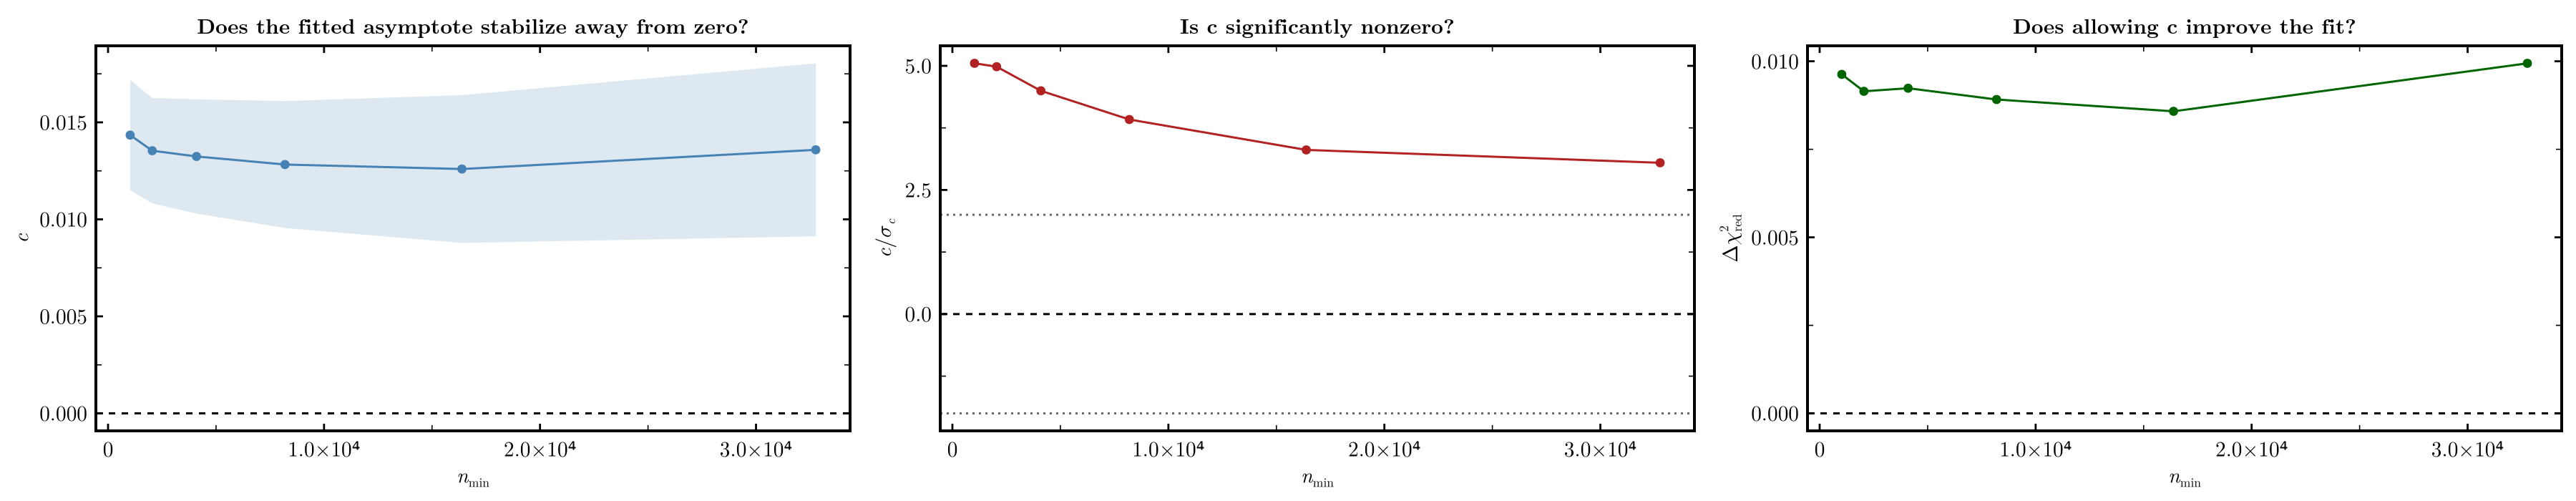

In [316]:
res_minkowski = tail_fit_zero_vs_const_log_4(Float64.(sizes_minkowski), Float64.(skew_means_minkowski), Float64.(skew_stds_minkowski))

apply_paper_theme!()

using CairoMakie
using Statistics

n_min_vals = [r.n_min for r in res_minkowski]
n_points_vals = [r.n_points for r in res_minkowski]

χ²_zero = [r.fit_zero.χ² for r in res_minkowski]
χ²_const = [r.fit_const.χ² for r in res_minkowski]

A_zero = [r.fit_zero.params.A for r in res_minkowski]

c_const = [r.fit_const.params.c for r in res_minkowski]
A_const = [r.fit_const.params.A for r in res_minkowski]

c_err = [r.fit_const.stderr.c for r in res_minkowski]
A_const_err = [r.fit_const.stderr.A for r in res_minkowski]


println("A_zero =$A_zero")
println("A_const =$A_const")
println("c_const =$c_const")
println("χ²_zero=$χ²_zero")
println("χ²_const=$χ²_const")

Δχ² = χ²_zero .- χ²_const
z_c = c_const ./ c_err

fig_summary = Figure(size = (1800, 350))

ax1 = Axis(
    fig_summary[1, 1];
    xlabel = L"n_{\min}",
    ylabel = L"c",
    title = "Does the fitted asymptote stabilize away from zero?",
)
band!(ax1, n_min_vals, c_const .- c_err, c_const .+ c_err; color = (:steelblue, 0.18))
lines!(ax1, n_min_vals, c_const; color = :steelblue)
scatter!(ax1, n_min_vals, c_const; color = :steelblue)
hlines!(ax1, [0.0]; color = :black, linestyle = :dash)

ax2 = Axis(
    fig_summary[1, 2];
    xlabel = L"n_{\min}",
    ylabel = L"c/\sigma_c",
    title = "Is c significantly nonzero?",
)
hlines!(ax2, [0.0]; color = :black, linestyle = :dash)
hlines!(ax2, [2.0]; color = :gray40, linestyle = :dot)
hlines!(ax2, [-2.0]; color = :gray40, linestyle = :dot)
lines!(ax2, n_min_vals, z_c; color = :firebrick)
scatter!(ax2, n_min_vals, z_c; color = :firebrick)

ax3 = Axis(
    fig_summary[1, 3];
    xlabel = L"n_{\min}",
    ylabel = L"\Delta \chi^2_{\mathrm{red}}",
    title = "Does allowing c improve the fit?",
)
hlines!(ax3, [0.0]; color = :black, linestyle = :dash)
lines!(ax3, n_min_vals, Δχ²; color = :darkgreen)
scatter!(ax3, n_min_vals, Δχ²; color = :darkgreen)


save(fig_path("graph_observables/degree_skew_size_scaling_minkowski_asymptotic.pdf"), fig_summary)


fig_summary